In [ ]:
"""
UMKM Go-Online — Full Pipeline
Step 1: Synthetic Data Generation (prior direvisi berdasarkan BPS E-Commerce 2023)
Step 2: Baseline ML Model (Logistic Regression + Random Forest + XGBoost)
Step 3: Evaluasi & SHAP Feature Importance

Referensi prior digitalisasi:
- BPS Statistik E-Commerce 2023 (bps.go.id)
  * WA/pesan instan: 95.33% (konteks: usaha yang SUDAH e-commerce → upper bound)
  * Media sosial: 33.29% (konteks sama → upper bound)
  * Website: 1.77% (populasi umum → dipakai langsung)
- LPEM FEB UI 2022 — Digitalisasi UMKM Indonesia
- Google/Temasek e-Conomy SEA 2023
"""

'\nUMKM Go-Online — Full Pipeline\nStep 1: Synthetic Data Generation (prior direvisi berdasarkan BPS E-Commerce 2023)\nStep 2: Baseline ML Model (Logistic Regression + Random Forest + XGBoost)\nStep 3: Evaluasi & SHAP Feature Importance\n\nReferensi prior digitalisasi:\n- BPS Statistik E-Commerce 2023 (bps.go.id)\n  * WA/pesan instan: 95.33% (konteks: usaha yang SUDAH e-commerce → upper bound)\n  * Media sosial: 33.29% (konteks sama → upper bound)  \n  * Website: 1.77% (populasi umum → dipakai langsung)\n- LPEM FEB UI 2022 — Digitalisasi UMKM Indonesia\n- Google/Temasek e-Conomy SEA 2023\n'

In [ ]:
"""
Versi 2 — Label Deterministik (Opsi A) — FINAL
Perubahan dari v1:
1. Label is_go_online dibuat dengan aturan deterministik (base_prob per sektor×skala)
   bukan probabilistik murni → model punya pola yang bisa dipelajari
2. Gap base_prob antar sektor di Mikro_Lv1 diperlebar agar sinyal kuat
   (89% data adalah Mikro_Lv1, perlu diferensiasi yang jelas)
3. Fitur omset_pct ditambahkan (posisi omset dalam range skalanya)
4. One-Hot Encoding untuk fitur nominal (sektor, kapanewon) — lebih tepat dari LabelEncoder
5. Ordinal Encoding tetap untuk skala usaha (ada hierarki Lv1 < Lv2 < ... < Menengah)
6. Pipeline sklearn dipakai agar preprocessing konsisten antara train dan test

Referensi prior digitalisasi:
- BPS Statistik E-Commerce 2023 (bps.go.id)
  * WA/pesan instan: 95.33% (konteks: usaha SUDAH e-commerce -> upper bound)
  * Media sosial: 33.29% (konteks sama -> upper bound)
  * Website: 1.77% (populasi umum -> dipakai langsung)
- LPEM FEB UI 2022 — Digitalisasi UMKM Indonesia
- Google/Temasek e-Conomy SEA 2023
- Bank Indonesia (2022): UMKM skala Kecil/Menengah 3x lebih mungkin go-digital
"""

'\nVersi 2 — Label Deterministik (Opsi A) — FINAL\nPerubahan dari v1:\n1. Label is_go_online dibuat dengan aturan deterministik (base_prob per sektor×skala)\n   bukan probabilistik murni → model punya pola yang bisa dipelajari\n2. Gap base_prob antar sektor di Mikro_Lv1 diperlebar agar sinyal kuat\n   (89% data adalah Mikro_Lv1, perlu diferensiasi yang jelas)\n3. Fitur omset_pct ditambahkan (posisi omset dalam range skalanya)\n4. One-Hot Encoding untuk fitur nominal (sektor, kapanewon) — lebih tepat dari LabelEncoder\n5. Ordinal Encoding tetap untuk skala usaha (ada hierarki Lv1 < Lv2 < ... < Menengah)\n6. Pipeline sklearn dipakai agar preprocessing konsisten antara train dan test\n \nReferensi prior digitalisasi:\n- BPS Statistik E-Commerce 2023 (bps.go.id)\n  * WA/pesan instan: 95.33% (konteks: usaha SUDAH e-commerce -> upper bound)\n  * Media sosial: 33.29% (konteks sama -> upper bound)\n  * Website: 1.77% (populasi umum -> dipakai langsung)\n- LPEM FEB UI 2022 — Digitalisasi UMKM I

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay, precision_recall_curve, f1_score, precision_score, recall_score, average_precision_score)

# 1. SYNTHETIC DATA GENERATION

In [3]:
np.random.seed(42)
N = 5000

In [4]:
# Distribusi Kapanewon (dari PDF rekap Sleman)
kapanewon_dist = {
    "Gamping": 7975, "Godean": 8057, "Moyudan": 5345,
    "Minggir": 4436, "Seyegan": 6053, "Mlati": 7457,
    "Depok": 10769, "Berbah": 5139, "Prambanan": 5054,
    "Kalasan": 8016, "Ngemplak": 5977, "Ngaglik": 8389,
    "Sleman": 9407, "Tempel": 7490, "Turi": 4213,
    "Pakem": 4367, "Cangkringan": 2787,
}
kap_names  = list(kapanewon_dist.keys())
kap_totals = np.array(list(kapanewon_dist.values()), dtype=float)
kap_probs  = kap_totals / kap_totals.sum()

# Distribusi Skala Usaha (dari kolom Jumlah per Skala — PDF rekap)
skala_dist = {
    "Mikro_Lv1": 99314, "Mikro_Lv2": 9205, "Mikro_Lv3": 1675,
    "Mikro_Lv4": 408,   "Mikro_Lv5": 143,  "Kecil": 174, "Menengah": 11,
}
skala_names  = list(skala_dist.keys())
skala_totals = np.array(list(skala_dist.values()), dtype=float)
skala_probs  = skala_totals / skala_totals.sum()

# 3 Sektor fokus (sesuai brief lomba)
AGRI  = "Agribisnis"
JASA  = "Jasa"
DAGANG = "Perdagangan"

# Proporsi dari PDF: Pertanian=6877, JasaLainnya=34997, Perdagangan=29176
sektor_raw_count = {AGRI: 6877, JASA: 34997, DAGANG: 29176}
sek_names  = list(sektor_raw_count.keys())
sek_totals = np.array(list(sektor_raw_count.values()), dtype=float)
sek_probs  = sek_totals / sek_totals.sum()

# Range omset per skala (Rupiah/bulan, dari kolom omset PDF)
omset_range = {
    "Mikro_Lv1": (500_000,    4_999_999),
    "Mikro_Lv2": (5_000_000,  9_999_999),
    "Mikro_Lv3": (10_000_000, 24_999_999),
    "Mikro_Lv4": (25_000_000, 49_999_999),
    "Mikro_Lv5": (50_000_000, 99_999_999),
    "Kecil":     (100_000_000, 999_999_999),
    "Menengah":  (1_000_000_000, 4_999_999_999),
}

tenaga_kerja_range = {
    "Mikro_Lv1": (1, 4),   "Mikro_Lv2": (1, 6),
    "Mikro_Lv3": (2, 8),   "Mikro_Lv4": (3, 15),
    "Mikro_Lv5": (5, 19),  "Kecil": (20, 99), "Menengah": (100, 300),
}

umur_usaha_range = {
    "Mikro_Lv1": (1, 5),  "Mikro_Lv2": (2, 8),   "Mikro_Lv3": (3, 12),
    "Mikro_Lv4": (5, 15), "Mikro_Lv5": (7, 20),  "Kecil": (5, 25), "Menengah": (10, 30),
}

In [6]:
# Prior Digitalisasi (BPS E-Commerce 2023)
p_wa = {AGRI: 0.22, JASA: 0.65, DAGANG: 0.50}
p_ig_given_wa = {AGRI: 0.12, JASA: 0.38, DAGANG: 0.30}
p_web_given_wa_ig = {AGRI: 0.03, JASA: 0.08, DAGANG: 0.06}

# Base probability go-online per kombinasi sektor x skala (aturan deterministik)
#
# Logika aturan:
# - Jasa (laundry, jastip): promosi via WA+IG sudah jadi kebutuhan utama
# - Perdagangan (kelontong): mulai sadar digital tapi masih banyak offline
# - Agribisnis: paling rendah — akses internet & literasi digital terbatas
#
# Gap antar sektor di Mikro_Lv1 SENGAJA diperlebar (0.04 / 0.18 / 0.09)
# karena 89% data ada di level ini — butuh sinyal yang kuat agar model bisa belajar.
# Referensi: BI (2022), BPS E-Commerce 2023, LPEM FEB UI (2022)

base_go_online_prob = {
    AGRI: {
        "Mikro_Lv1": 0.04,
        "Mikro_Lv2": 0.08,
        "Mikro_Lv3": 0.15,
        "Mikro_Lv4": 0.25,
        "Mikro_Lv5": 0.35,
        "Kecil":     0.50,
        "Menengah":  0.65,
    },
    JASA: {
        "Mikro_Lv1": 0.18,
        "Mikro_Lv2": 0.32,
        "Mikro_Lv3": 0.55,
        "Mikro_Lv4": 0.72,
        "Mikro_Lv5": 0.82,
        "Kecil":     0.90,
        "Menengah":  0.95,
    },
    DAGANG: {
        "Mikro_Lv1": 0.09,
        "Mikro_Lv2": 0.20,
        "Mikro_Lv3": 0.38,
        "Mikro_Lv4": 0.55,
        "Mikro_Lv5": 0.68,
        "Kecil":     0.80,
        "Menengah":  0.90,
    },
}


In [7]:
# Noise kecil agar data tidak terlalu "kotak-kotak" — tetap realistis
NOISE_STD = 0.04
URBAN_AREAS = {"Depok", "Mlati", "Gamping", "Ngaglik", "Kalasan"}

def clamp(p, lo=0.01, hi=0.96):
    return max(lo, min(hi, p))

# Generate rows
rows = []
for _ in range(N):
    kapanewon = np.random.choice(kap_names,   p=kap_probs)
    skala     = np.random.choice(skala_names, p=skala_probs)
    sektor    = np.random.choice(sek_names,   p=sek_probs)

    lo, hi = omset_range[skala]
    omset  = np.random.randint(lo, hi + 1)
    omset_pct = (omset - lo) / (hi - lo)   # posisi relatif dalam range skala (0-1)

    lo_tk, hi_tk = tenaga_kerja_range[skala]
    total_tk     = np.random.randint(lo_tk, hi_tk + 1)
    tk_laki      = int(round(total_tk * np.random.uniform(0.45, 0.60)))
    tk_perempuan = total_tk - tk_laki

    lo_u, hi_u = umur_usaha_range[skala]
    umur_usaha = np.random.randint(lo_u, hi_u + 1)
    umur_bonus = (umur_usaha / 30) * 0.05

    # 1. Bikin bobot untuk lokasi (Urban vs Rural)
    lokasi_bonus = 0.15 if kapanewon in URBAN_AREAS else -0.05

    # 2. Bikin bobot untuk tenaga kerja (makin banyak TK = makin profesional)
    # Posisi TK dalam range skalanya (0-1), mirip logika omset_pct
    tk_pct  = (total_tk - lo_tk) / max(hi_tk - lo_tk, 1)
    tk_bonus = tk_pct * 0.08  # max +0.08 untuk TK terbanyak di skalanya

    # Label deterministik: base_prob + kontribusi omset + noise kecil
    base_prob    = base_go_online_prob[sektor][skala]
    final_prob   = clamp(base_prob + (omset_pct * 0.08) + lokasi_bonus + tk_bonus + umur_bonus + np.random.normal(0, NOISE_STD))
    is_go_online = int(np.random.random() < final_prob)

    # Indikator digital (konsisten dengan label, untuk EDA & validasi — BUKAN fitur ML)
    if is_go_online == 1:
        punya_wa      = 1
        punya_ig      = int(np.random.random() < 0.88)
        punya_website = int(np.random.random() < p_web_given_wa_ig[sektor] * 2)
    else:
        punya_wa      = int(np.random.random() < p_wa[sektor] * 0.45)
        punya_ig      = 0
        punya_website = 0

    digital_score = punya_wa + punya_ig + punya_website

    rows.append({
        "kapanewon":              kapanewon,
        "sektor_usaha":           sektor,
        "skala_usaha":            skala,
        "omset_per_bulan":        omset,
        "omset_pct_dalam_skala":  round(omset_pct, 4),
        "tenaga_kerja_total":     total_tk,
        "tenaga_kerja_laki":      tk_laki,
        "tenaga_kerja_perempuan": tk_perempuan,
        "punya_whatsapp":         punya_wa,
        "punya_instagram":        punya_ig,
        "punya_website":          punya_website,
        "digital_score":          digital_score,
        "is_go_online":           is_go_online,
        "is_urban":               int(kapanewon in URBAN_AREAS),
        "umur_usaha":             umur_usaha
    })

df = pd.DataFrame(rows)

In [8]:
print(f"\nDataset shape   : {df.shape}")
print(f"Go-Online (1)   : {df['is_go_online'].sum()} ({df['is_go_online'].mean()*100:.1f}%)")
print(f"Tidak G-O (0)   : {(df['is_go_online']==0).sum()} ({(df['is_go_online']==0).mean()*100:.1f}%)")
print("\nGo-Online rate per sektor:")
print(df.groupby("sektor_usaha")["is_go_online"].mean().apply(lambda x: f"{x*100:.1f}%"))
print("\nGo-Online rate per skala:")
go_per_skala = df.groupby("skala_usaha")["is_go_online"].mean() * 100
print(go_per_skala.reindex(skala_names).apply(lambda x: f"{x:.1f}%" if not np.isnan(x) else "N/A"))


Dataset shape   : (5000, 15)
Go-Online (1)   : 1257 (25.1%)
Tidak G-O (0)   : 3743 (74.9%)

Go-Online rate per sektor:
sektor_usaha
Agribisnis     15.2%
Jasa           31.4%
Perdagangan    20.0%
Name: is_go_online, dtype: object

Go-Online rate per skala:
skala_usaha
Mikro_Lv1     22.9%
Mikro_Lv2     38.9%
Mikro_Lv3     57.6%
Mikro_Lv4     80.8%
Mikro_Lv5     55.6%
Kecil         87.5%
Menengah     100.0%
Name: is_go_online, dtype: object


In [9]:
df.to_csv("umkm_synthetic_sleman.csv", index=False)
print("Dataset tersimpan sebagai umkm_synthetic_sleman.csv")

Dataset tersimpan sebagai umkm_synthetic_sleman.csv


In [10]:
# DATA CLEANING & VALIDASI

# Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())

Missing values per kolom:
kapanewon                 0
sektor_usaha              0
skala_usaha               0
omset_per_bulan           0
omset_pct_dalam_skala     0
tenaga_kerja_total        0
tenaga_kerja_laki         0
tenaga_kerja_perempuan    0
punya_whatsapp            0
punya_instagram           0
punya_website             0
digital_score             0
is_go_online              0
is_urban                  0
umur_usaha                0
dtype: int64

Jumlah duplikat: 0

Omset min: Rp 500,503
Omset max: Rp 4,264,103,721

Konsistensi TK (laki+perempuan=total): True

Class balance:
is_go_online
0    74.9%
1    25.1%
Name: proportion, dtype: object

Distribusi Sektor:
sektor_usaha
Jasa           2449
Perdagangan    2077
Agribisnis      474
Name: count, dtype: int64


In [ ]:
# Cek duplikat
print(f"\nJumlah duplikat: {df.duplicated().sum()}")

In [ ]:
# Cek outlier omset (seharusnya 0 karena range kita kontrol)
print(f"\nOmset min: Rp {df['omset_per_bulan'].min():,.0f}")
print(f"Omset max: Rp {df['omset_per_bulan'].max():,.0f}")

In [ ]:
# Cek konsistensi: tk_laki + tk_perempuan == tk_total
tk_check = (df["tenaga_kerja_laki"] + df["tenaga_kerja_perempuan"]) == df["tenaga_kerja_total"]
print(f"\nKonsistensi TK (laki+perempuan=total): {tk_check.all()}")

In [ ]:
# Cek class balance
print(f"\nClass balance:")
print(df["is_go_online"].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

In [ ]:
# Cek distribusi setiap kolom kategorik
print("\nDistribusi Sektor:")
print(df["sektor_usaha"].value_counts())

# 2. EXPLORATORY DATA ANALYSIS

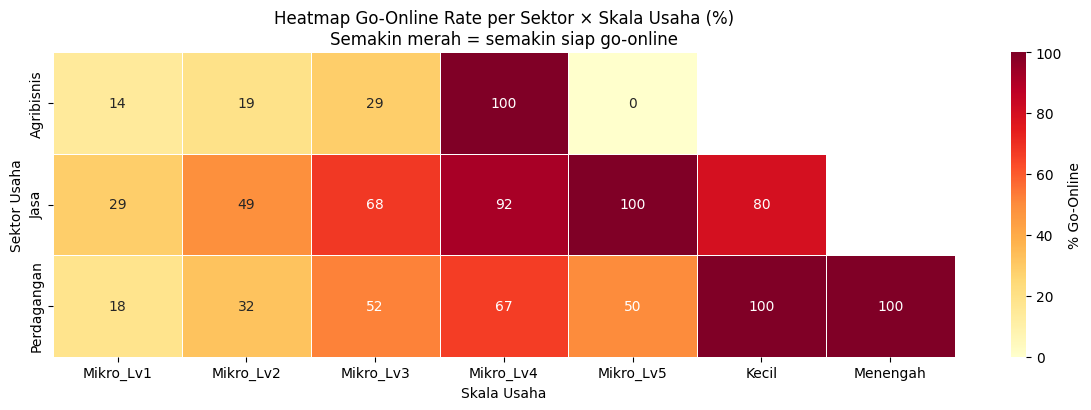

In [11]:
# 1. Heatmap: Go-Online rate per Sektor × Skala
pivot = df.groupby(["sektor_usaha", "skala_usaha"])["is_go_online"].mean() * 100
pivot = pivot.unstack().reindex(columns=skala_names)

plt.figure(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "% Go-Online"})
plt.title("Heatmap Go-Online Rate per Sektor × Skala Usaha (%)")
plt.tight_layout()
plt.title("Heatmap Go-Online Rate per Sektor × Skala Usaha (%)\n"
          "Semakin merah = semakin siap go-online")
plt.xlabel("Skala Usaha")
plt.ylabel("Sektor Usaha")
plt.show()

> Menjawab: "Faktor apa yang memicu UMKM go-online?"

> Kenapa powerful: juri langsung lihat bahwa Jasa + Kecil paling siap, Agribisnis + Mikro_Lv1 paling tidak siap — satu gambar menjawab research question 1.

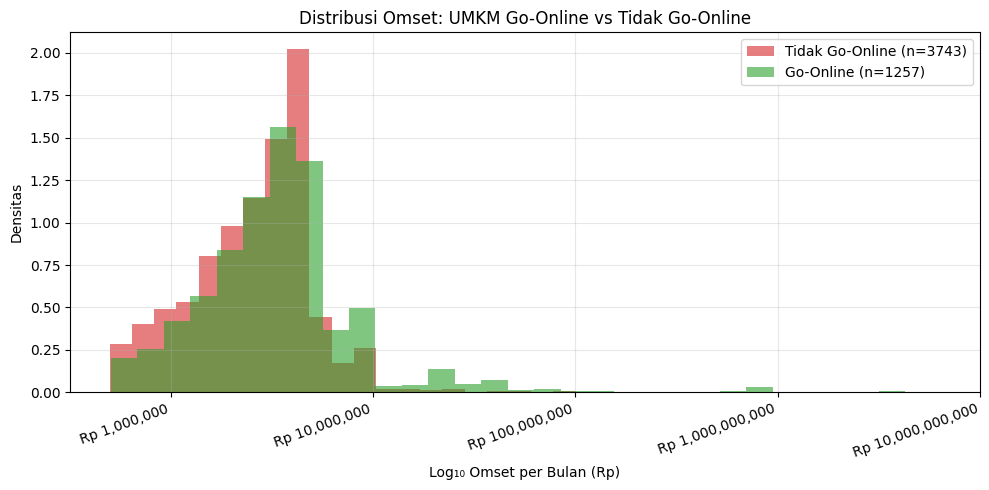

In [12]:
# 2. Perbandingan Distribusi Omset: Go-Online vs Tidak
fig, ax = plt.subplots(figsize=(10, 5))

df_go   = df[df["is_go_online"] == 1]["omset_per_bulan"]
df_nogo = df[df["is_go_online"] == 0]["omset_per_bulan"]

ax.hist(np.log10(df_nogo + 1), bins=30, alpha=0.6, color="#d62728",
        label=f"Tidak Go-Online (n={len(df_nogo)})", density=True)
ax.hist(np.log10(df_go + 1),   bins=30, alpha=0.6, color="#2ca02c",
        label=f"Go-Online (n={len(df_go)})",         density=True)

ax.set_xlabel("Log₁₀ Omset per Bulan (Rp)")
ax.set_ylabel("Densitas")
ax.set_title("Distribusi Omset: UMKM Go-Online vs Tidak Go-Online")
ax.legend(); ax.grid(alpha=0.3)

# Tambah label tick yang readable
ticks = [6, 7, 8, 9, 10]
ax.set_xticks(ticks)
ax.set_xticklabels([f"Rp {10**t:,.0f}" for t in ticks], rotation=20, ha="right")
plt.tight_layout(); plt.show()

> Kenapa powerful: kalau distribusi hijau (go-online) bergeser ke kanan dari merah, itu bukti visual bahwa omset berkorelasi dengan kesiapan digital.

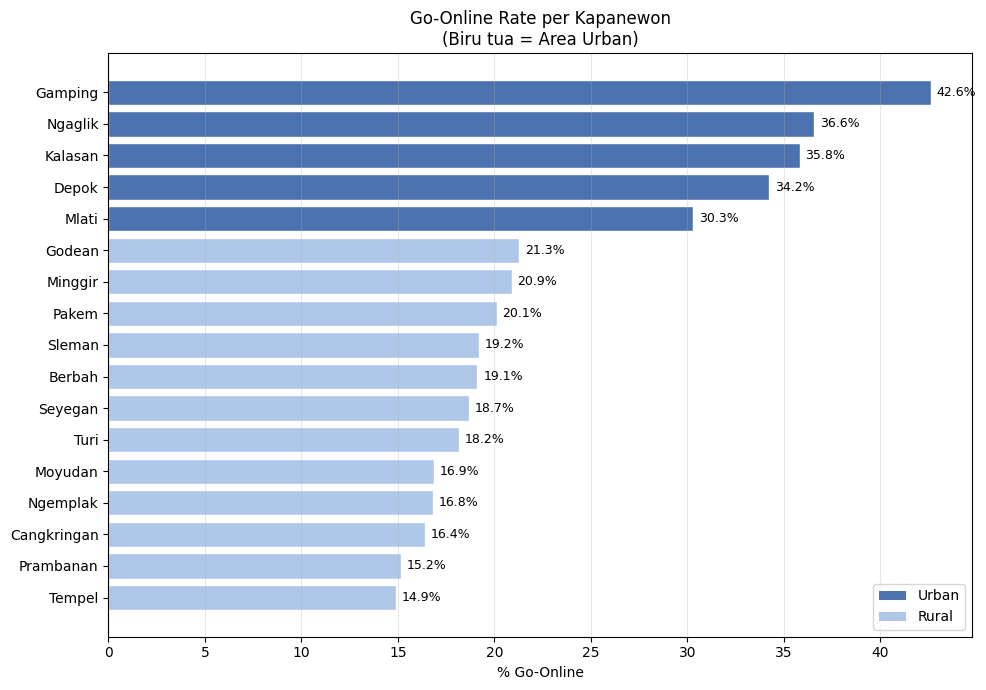

In [13]:
# 3. Go-Online Rate per Kapanewon (Bar Chart Horizontal)
rate_kap = (df.groupby("kapanewon")["is_go_online"]
              .mean()
              .sort_values(ascending=True) * 100)

# Warna urban vs rural
URBAN_AREAS = {"Depok", "Mlati", "Gamping", "Ngaglik", "Kalasan"}
bar_colors = ["#4C72B0" if k in URBAN_AREAS else "#aec7e8"
              for k in rate_kap.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(rate_kap.index, rate_kap.values,
               color=bar_colors, edgecolor="white")

for bar, val in zip(bars, rate_kap.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#4C72B0", label="Urban"),
                   Patch(facecolor="#aec7e8", label="Rural")]
ax.legend(handles=legend_elements, loc="lower right")

ax.set_xlabel("% Go-Online")
ax.set_title("Go-Online Rate per Kapanewon\n(Biru tua = Area Urban)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

> Menjawab: "Apakah lokasi berpengaruh?"

> Kenapa powerful: visual ini membuktikan bahwa urban areas punya go-online rate lebih tinggi — memperkuat keputusan design data kamu di depan juri.

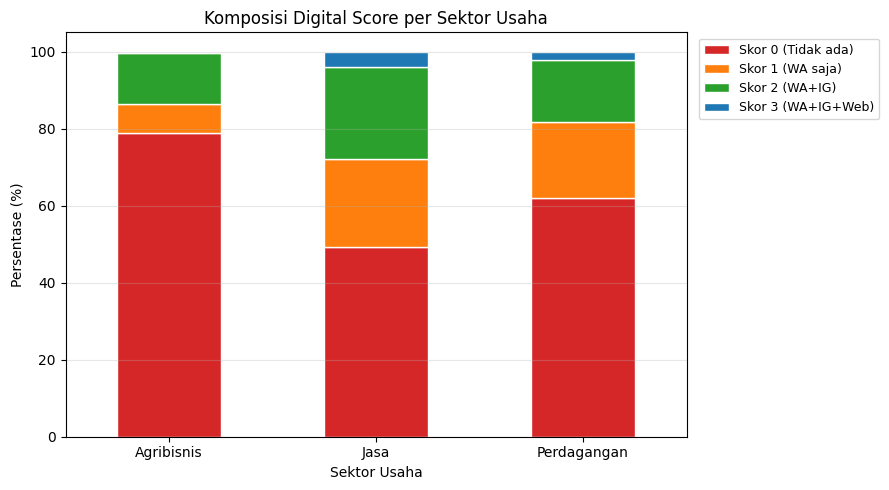

In [14]:
# 4. Stacked Bar: Komposisi Digital Score per Sektor
score_by_sektor = (df.groupby(["sektor_usaha", "digital_score"])
                     .size()
                     .unstack(fill_value=0))
score_by_sektor_pct = score_by_sektor.div(score_by_sektor.sum(axis=1), axis=0) * 100

score_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
score_legend = ["Skor 0 (Tidak ada)", "Skor 1 (WA saja)",
                "Skor 2 (WA+IG)", "Skor 3 (WA+IG+Web)"]

fig, ax = plt.subplots(figsize=(9, 5))
score_by_sektor_pct.plot(kind="bar", stacked=True, ax=ax,
                          color=score_colors, edgecolor="white", width=0.5)

ax.set_xlabel("Sektor Usaha"); ax.set_ylabel("Persentase (%)")
ax.set_title("Komposisi Digital Score per Sektor Usaha")
ax.legend(score_legend, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

> Menjawab: "Seberapa jauh gap digitalisasi antar sektor?"

> Kenapa powerful: juri bisa lihat seberapa "merah" (skor 0) komposisi Agribisnis dibanding Jasa — secara langsung mendukung argumen kenapa ketiga sektor ini dipilih sebagai fokus studi.

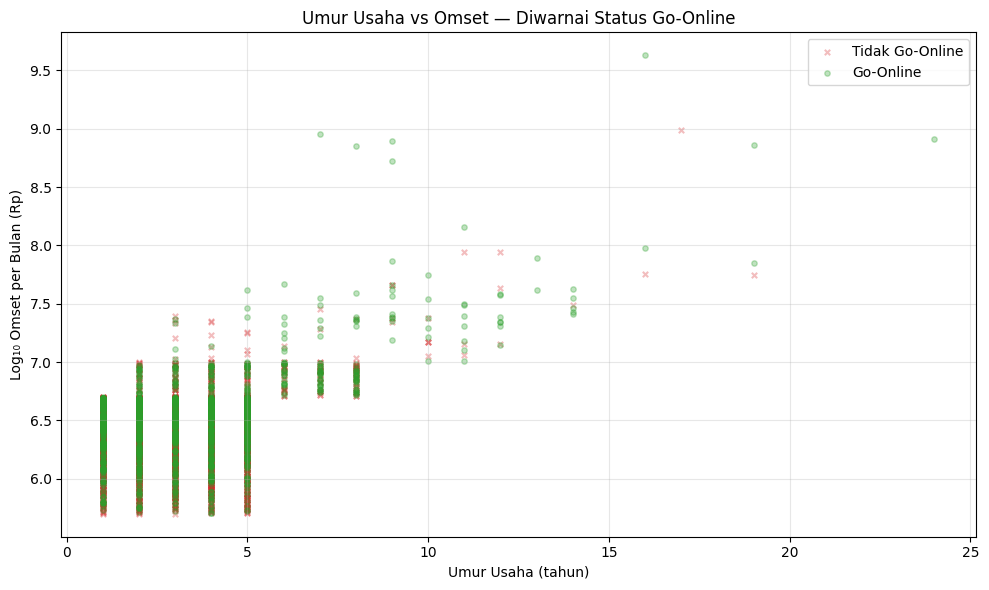

In [15]:
# 5. Scatter: Umur Usaha vs Omset, warna = Go-Online
fig, ax = plt.subplots(figsize=(10, 6))

for label, color, marker in [(0, "#d62728", "x"), (1, "#2ca02c", "o")]:
    sub = df[df["is_go_online"] == label]
    ax.scatter(sub["umur_usaha"],
               np.log10(sub["omset_per_bulan"] + 1),
               c=color, marker=marker, alpha=0.3, s=15,
               label="Go-Online" if label == 1 else "Tidak Go-Online")

ax.set_xlabel("Umur Usaha (tahun)")
ax.set_ylabel("Log₁₀ Omset per Bulan (Rp)")
ax.set_title("Umur Usaha vs Omset — Diwarnai Status Go-Online")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

> Menjawab: "Apakah UMKM yang lebih tua dan beromset lebih tinggi lebih siap go-online?"

> Kenapa powerful: kalau titik hijau (go-online) cenderung di pojok kanan-atas (tua + omset tinggi), itu konfirmasi visual dari dua fitur sekaligus. Ini jenis plot yang juri suka karena informatif dan engaging.

*   EDA 1 → Siapa yang go-online? (Heatmap sektor×skala)
*   EDA 2 → Omset berpengaruh? (Distribusi)
*   EDA 3 → Lokasi berpengaruh? (Bar kapanewon)
*   EDA 4 → Seberapa parah gap-nya? (Stacked bar digital score)
*   EDA 5 → Umur + omset = siap? (Scatter)



# 3. FEATURE ENGINEERING & PREPROCESSING

In [16]:
df_ml = df.copy()

# Skala usaha -> ordinal (BOLEH karena ada hierarki: Lv1 < Lv2 < ... < Menengah)
skala_order = {s: i for i, s in enumerate(skala_names)}
df_ml["skala_enc"] = df_ml["skala_usaha"].map(skala_order)

# Log omset — range omset sangat lebar, log lebih informatif
df_ml["log_omset"] = np.log1p(df_ml["omset_per_bulan"])

# Rasio tenaga kerja perempuan
df_ml["rasio_perempuan"] = (df_ml["tenaga_kerja_perempuan"]
                            / df_ml["tenaga_kerja_total"].replace(0, 1))

# Fitur kategorik nominal -> One-Hot Encoding
# Alasan: sektor & kapanewon tidak punya urutan numerik
CAT_FEATURES = ["sektor_usaha", "kapanewon"]
NUM_FEATURES  = [
    "skala_enc",
    "log_omset",
    "omset_pct_dalam_skala",
    "tenaga_kerja_total",
    "rasio_perempuan",
    "is_urban",
    "umur_usaha",
]
TARGET = "is_go_online"

In [17]:
X = df_ml[CAT_FEATURES + NUM_FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
preprocessor = ColumnTransformer([
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
    ("num", StandardScaler(), NUM_FEATURES),
])

In [19]:
print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"Class balance (train) — 1: {y_train.sum()} | 0: {(y_train==0).sum()}")

Train size : 4000
Test size  : 1000
Class balance (train) — 1: 1006 | 0: 2994


# 4. TRAINING BASELINE MODELS

Tiga model dipilih untuk perbandingan:
- Logistic Regression: baseline linear, interpretable, cocok untuk imbalanced dengan class_weight
- Random Forest: ensemble tree, robust terhadap outlier, bisa capture nonlinear
- Gradient Boosting: sequential boosting, biasanya best performer untuk tabular data
> Semua model pakai class_weight="balanced" karena label imbalanced (83:17)

In [20]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, C=0.5, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.08, random_state=42
    ),
}

results = {}

In [21]:
for name, model in models.items():
    print(f"\n {name}")

    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()

    print(classification_report(y_test, y_pred, target_names=["Tidak GO", "GO Online"]))
    print(f"  ROC-AUC      : {auc:.4f}")
    print(f"  CV ROC-AUC   : {cv:.4f} (5-fold)")

    results[name] = {
        "pipe": pipe, "y_pred": y_pred, "y_prob": y_prob, "auc": auc, "cv_auc": cv
    }

best_name = max(results, key=lambda k: results[k]["auc"])
print(f"\nBest Model: {best_name} (AUC = {results[best_name]['auc']:.4f})")


 Logistic Regression
              precision    recall  f1-score   support

    Tidak GO       0.85      0.68      0.76       749
   GO Online       0.40      0.65      0.50       251

    accuracy                           0.67      1000
   macro avg       0.63      0.66      0.63      1000
weighted avg       0.74      0.67      0.69      1000

  ROC-AUC      : 0.7354
  CV ROC-AUC   : 0.6814 (5-fold)

 Random Forest
              precision    recall  f1-score   support

    Tidak GO       0.78      0.92      0.84       749
   GO Online       0.48      0.22      0.30       251

    accuracy                           0.74      1000
   macro avg       0.63      0.57      0.57      1000
weighted avg       0.70      0.74      0.71      1000

  ROC-AUC      : 0.6649
  CV ROC-AUC   : 0.6294 (5-fold)

 Gradient Boosting
              precision    recall  f1-score   support

    Tidak GO       0.77      0.97      0.86       749
   GO Online       0.57      0.12      0.19       251

    accura

In [25]:
f1  = f1_score(y_test, y_pred, pos_label=1)
pr_auc = average_precision_score(y_test, y_prob)  # Precision-Recall AUC — lebih informatif untuk imbalanced

results[name] = {
    "pipe": pipe, "y_pred": y_pred, "y_prob": y_prob,
    "auc": auc, "cv_auc": cv, "f1": f1, "pr_auc": pr_auc
}

# 5. VISUALISASI

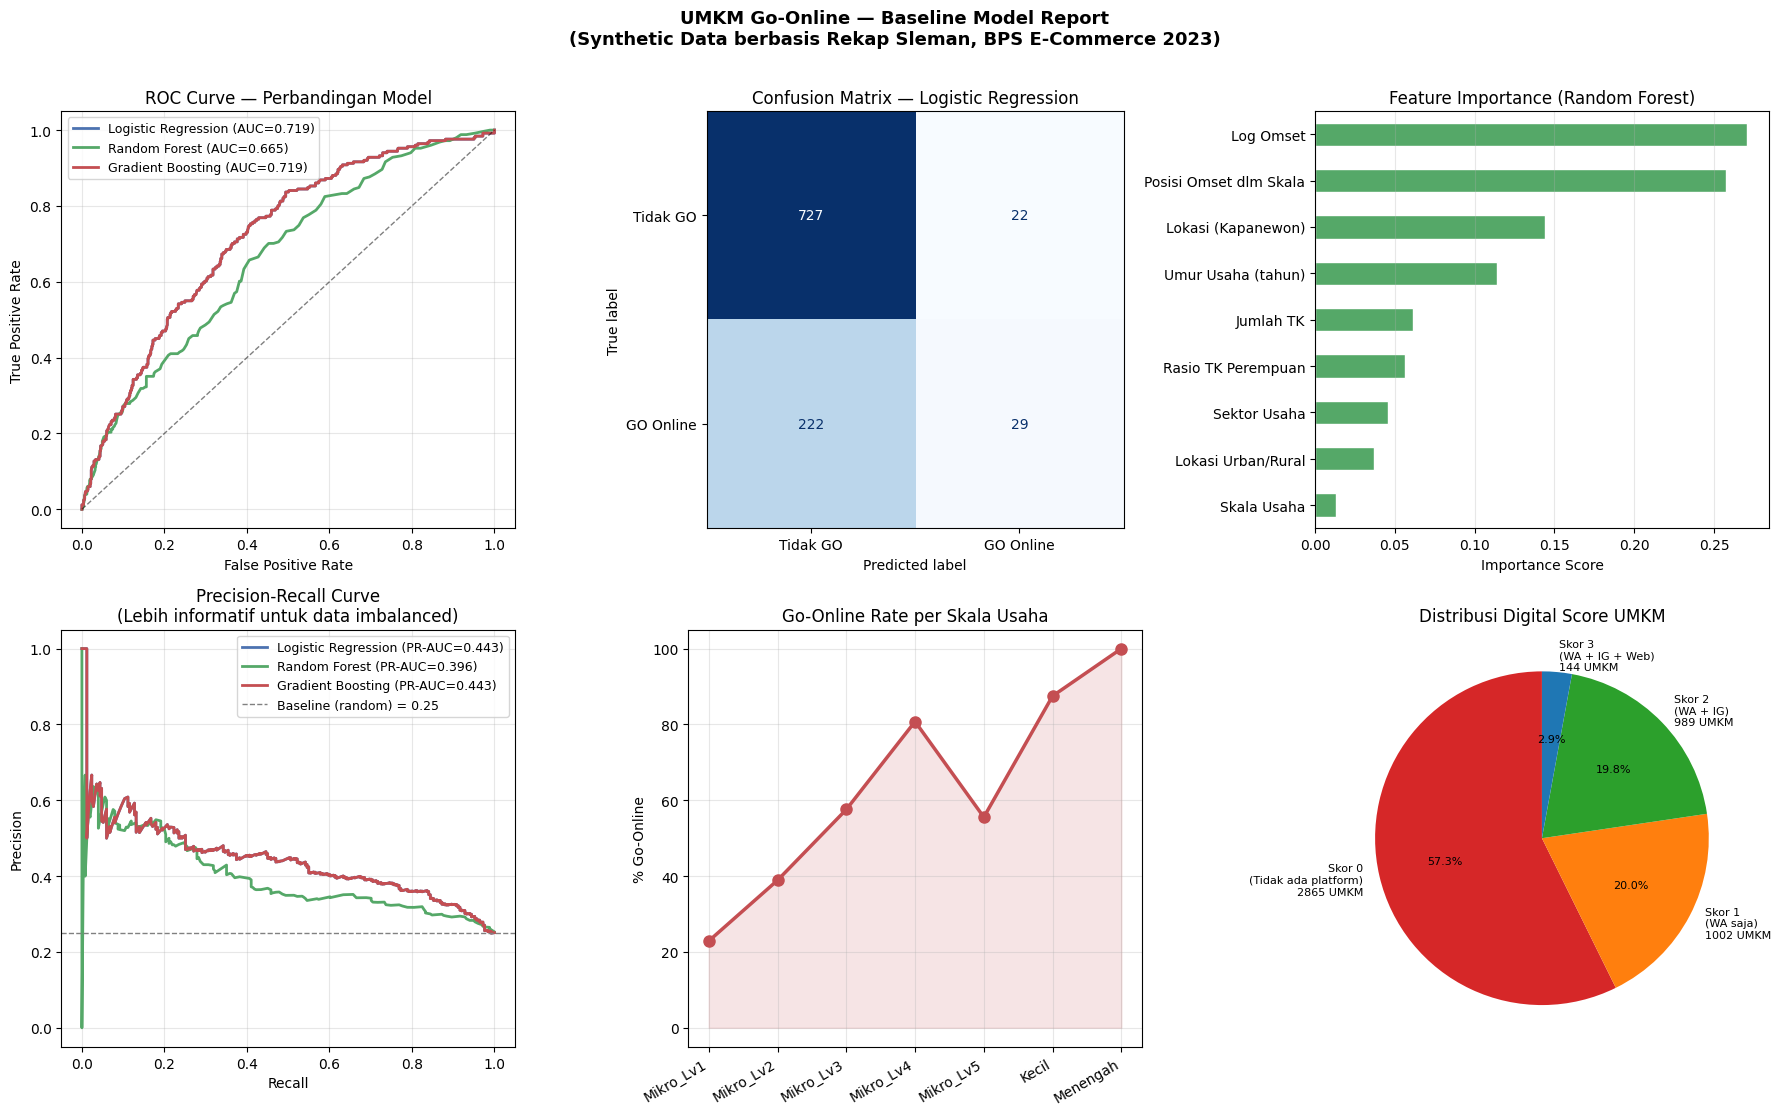

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("UMKM Go-Online — Baseline Model Report\n(Synthetic Data berbasis Rekap Sleman, BPS E-Commerce 2023)",
             fontsize=13, fontweight="bold", y=1.01)

colors = {"Logistic Regression": "#4C72B0",
          "Random Forest":       "#55A868",
          "Gradient Boosting":   "#C44E52"}

for name, res in results.items():
    if "f1" not in res:
        results[name]["f1"] = f1_score(y_test, res["y_pred"], pos_label=1)
    if "pr_auc" not in res:
        results[name]["pr_auc"] = average_precision_score(y_test, res["y_prob"])

# Plot 1: ROC Curve
ax = axes[0, 0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})",
            color=colors[name], lw=2)
ax.plot([0,1],[0,1],"k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Perbandingan Model")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Plot 2: Confusion Matrix (best model)
ax = axes[0, 1]
best = results[best_name]
cm = confusion_matrix(y_test, best["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Tidak GO", "GO Online"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_name}")

# Plot 3: Feature Importance (Random Forest, diagregasi per grup fitur)
ax = axes[0, 2]
rf_pipe = results["Random Forest"]["pipe"]
ohe_features = (rf_pipe.named_steps["prep"]
                .named_transformers_["ohe"]
                .get_feature_names_out(CAT_FEATURES)
                .tolist())
all_feature_names = ohe_features + NUM_FEATURES
rf_importances   = rf_pipe.named_steps["clf"].feature_importances_

feat_imp_dict = {}
feat_label_map = {
    "skala_enc":             "Skala Usaha",
    "log_omset":             "Log Omset",
    "omset_pct_dalam_skala": "Posisi Omset dlm Skala",
    "tenaga_kerja_total":    "Jumlah TK",
    "rasio_perempuan":       "Rasio TK Perempuan",
    "is_urban":              "Lokasi Urban/Rural",
    "umur_usaha":            "Umur Usaha (tahun)",
}
for fname, imp in zip(all_feature_names, rf_importances):
    if fname.startswith("sektor_usaha"):
        key = "Sektor Usaha"
    elif fname.startswith("kapanewon"):
        key = "Lokasi (Kapanewon)"
    else:
        key = feat_label_map.get(fname, fname)
    feat_imp_dict[key] = feat_imp_dict.get(key, 0) + imp

feat_series = pd.Series(feat_imp_dict).sort_values(ascending=True)
feat_series.plot(kind="barh", ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Feature Importance (Random Forest)")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)

# Plot 4: Go-Online Rate per Sektor
ax = axes[1, 0]
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    ax.plot(rec, prec, label=f"{name} (PR-AUC={res['pr_auc']:.3f})",
            color=colors[name], lw=2)
baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", lw=1,
           label=f"Baseline (random) = {baseline:.2f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve\n(Lebih informatif untuk data imbalanced)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Plot 5: Go-Online Rate per Skala
ax = axes[1, 1]
rate_skala = df.groupby("skala_usaha")["is_go_online"].mean() * 100
rate_skala = rate_skala.reindex(skala_names)
ax.plot(rate_skala.index, rate_skala.values, marker="o", color="#C44E52",
        lw=2.5, markersize=8)
ax.fill_between(rate_skala.index, rate_skala.values, alpha=0.15, color="#C44E52")
ax.set_title("Go-Online Rate per Skala Usaha")
ax.set_ylabel("% Go-Online")
ax.set_xticklabels(rate_skala.index, rotation=30, ha="right")
ax.grid(alpha=0.3)

# Plot 6: Distribusi Digital Score
ax = axes[1, 2]
score_dist = df["digital_score"].value_counts().sort_index()
score_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
score_labels = [
    f"Skor 0\n(Tidak ada platform)\n{score_dist.get(0,0)} UMKM",
    f"Skor 1\n(WA saja)\n{score_dist.get(1,0)} UMKM",
    f"Skor 2\n(WA + IG)\n{score_dist.get(2,0)} UMKM",
    f"Skor 3\n(WA + IG + Web)\n{score_dist.get(3,0)} UMKM",
]
ax.pie(
    score_dist.values, labels=score_labels, colors=score_colors,
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 8}
)
ax.set_title("Distribusi Digital Score UMKM")

plt.tight_layout()
plt.show()

In [28]:
# Summary tabel model
print("RINGKASAN PERFORMA MODEL")
print(f"{'Model':<25} {'AUC':>8} {'CV-AUC':>10} {'F1':>8} {'PR-AUC':>8}")
print("-" * 62)
for name, res in results.items():
    marker = " ← BEST" if name == best_name else ""
    print(f"{name:<25} {res['auc']:>8.4f} {res['cv_auc']:>10.4f} "
          f"{res['f1']:>8.4f} {res['pr_auc']:>8.4f}{marker}")

RINGKASAN PERFORMA MODEL
Model                          AUC     CV-AUC       F1   PR-AUC
--------------------------------------------------------------
Logistic Regression         0.7190     0.6751   0.1921   0.4426 ← BEST
Random Forest               0.6649     0.6294   0.3014   0.3961
Gradient Boosting           0.7190     0.6751   0.1921   0.4426
